# PW3: Mice's sleep stages classification with MLP

Group:

- David Schildböck
- Kénan Augsburger

Goals:

- Prepare and pre-process the available data to train a neural-network for solving a classification task.
- Design experiments to exploit the available data to come up with an automatic classification system.
- Design, train and evaluate neural networks (Multi-Layer Perceptron) to solve a real-world problem.
- Perform hyper-parameter tuning to find an appropriate neural network architecture and to achieve a good performing model.


## Introduction

In [1]:
# Basic imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm.notebook import tqdm


# Setting up the visualisation style
sns.set_theme(style="whitegrid")

### Training data:

- EEG_mouse_data_1.csv (same mouse as PW1)
- EEG_mouse_data_2.csv (another mouse for training)

Note: if you want to concatenate pandas dataframes, you can do it with « pd.concat ».

In [2]:
raw_train_data_1 = pd.read_csv("pw3_data/EEG_mouse_data_1.csv")
raw_train_data_2 = pd.read_csv("pw3_data/EEG_mouse_data_2.csv")
raw_train_data = pd.concat([raw_train_data_1, raw_train_data_2], ignore_index=True)

### Testing data:

- EEG_mouse_data_test.csv (another mouse for testing)

All of these mice are genetical clones of each other so the data will be slightly different from
mouse to mouse but will still be similar.  
We don't provide any notebook. You can use code of previous practical works to help you. You
can choose whether you want to do it on Colab or not.


In [3]:
raw_test_data = pd.read_csv("pw3_data/EEG_mouse_data_test.csv")

### Preprocessing:

- Choose 25 features
- Normalize data

see: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html


In [4]:
# Exploring the datasets

raw_test_data.describe()

,amplitude_around_1_Hertz,amplitude_around_2_Hertz,amplitude_around_3_Hertz,amplitude_around_4_Hertz,amplitude_around_5_Hertz,amplitude_around_6_Hertz,amplitude_around_7_Hertz,amplitude_around_8_Hertz,amplitude_around_9_Hertz,amplitude_around_10_Hertz,...,amplitude_around_92_Hertz,amplitude_around_93_Hertz,amplitude_around_94_Hertz,amplitude_around_95_Hertz,amplitude_around_96_Hertz,amplitude_around_97_Hertz,amplitude_around_98_Hertz,amplitude_around_99_Hertz,amplitude_around_100_Hertz,amplitude_around_101_Hertz
count,80109.000000,80109.000000,80109.000000,80109.000000,80109.000000,80109.000000,80109.000000,80109.000000,80109.000000,80109.000000,...,8.010900e+04,8.010900e+04,8.010900e+04,8.010900e+04,8.010900e+04,8.010900e+04,8.010900e+04,8.010900e+04,8.010900e+04,8.010900e+04
mean,-0.000023,0.000015,0.000016,0.000016,0.000014,0.000012,0.000013,0.000013,0.000010,0.000007,...,9.927835e-09,7.624872e-09,5.687167e-09,4.156366e-09,3.009007e-09,2.124984e-09,1.519217e-09,1.131444e-09,1.037376e-09,-1.997249e-04
std,0.003534,0.000018,0.000018,0.000016,0.000014,0.000011,0.000012,0.000012,0.000009,0.000007,...,8.602050e-09,6.664576e-09,4.960118e-09,3.668513e-09,2.606265e-09,1.796833e-09,1.273646e-09,9.540812e-10,8.455716e-10,1.413119e-02
min,-0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,0.000005,0.000005,0.000005,0.000005,0.000005,0.000004,0.000005,0.000005,0.000004,0.000003,...,4.278843e-09,3.244971e-09,2.438945e-09,1.796409e-09,1.308106e-09,9.408982e-10,6.787478e-10,5.071618e-10,4.835167e-10,2.897480e-10
50%,0.000012,0.000009,0.000010,0.000010,0.000009,0.000008,0.000009,0.000009,0.000007,0.000005,...,7.447277e-09,5.702682e-09,4.262453e-09,3.121290e-09,2.265915e-09,1.610378e-09,1.155194e-09,8.629032e-10,8.128287e-10,1.319130e-09
75%,0.000026,0.000018,0.000020,0.000020,0.000018,0.000015,0.000016,0.000016,0.000013,0.000009,...,1.275024e-08,9.848925e-09,7.301070e-09,5.344233e-09,3.873223e-09,2.741333e-09,1.956633e-09,1.452218e-09,1.331247e-09,3.895100e-09
max,0.007021,0.000375,0.000326,0.000272,0.000245,0.000167,0.000167,0.000215,0.000150,0.000101,...,1.511856e-07,1.433177e-07,9.574633e-08,1.375192e-07,5.607566e-08,4.832078e-08,3.697477e-08,3.940120e-08,2.649568e-08,2.951280e-07


In [5]:
raw_train_data.describe()

,amplitude_around_1_Hertz,amplitude_around_2_Hertz,amplitude_around_3_Hertz,amplitude_around_4_Hertz,amplitude_around_5_Hertz,amplitude_around_6_Hertz,amplitude_around_7_Hertz,amplitude_around_8_Hertz,amplitude_around_9_Hertz,amplitude_around_10_Hertz,...,amplitude_around_92_Hertz,amplitude_around_93_Hertz,amplitude_around_94_Hertz,amplitude_around_95_Hertz,amplitude_around_96_Hertz,amplitude_around_97_Hertz,amplitude_around_98_Hertz,amplitude_around_99_Hertz,amplitude_around_100_Hertz,amplitude_around_101_Hertz
count,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,...,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04
mean,1.444232e-05,1.502917e-05,1.434708e-05,1.441615e-05,1.292851e-05,1.116549e-05,1.186056e-05,1.210683e-05,1.010482e-05,7.144605e-06,...,1.763867e-08,1.351433e-08,1.012838e-08,7.345691e-09,5.226716e-09,3.629456e-09,2.505175e-09,1.803339e-09,3.348605e-09,3.743263e-08
std,2.533504e-05,1.674479e-05,1.441490e-05,1.404950e-05,1.210619e-05,9.720546e-06,1.080766e-05,1.075301e-05,8.981800e-06,6.475928e-06,...,1.268618e-08,9.692037e-09,7.208488e-09,5.269660e-09,3.698496e-09,2.589742e-09,1.769041e-09,1.245381e-09,2.309435e-09,3.680916e-08
min,9.721140e-08,1.007709e-07,1.170355e-07,1.393710e-07,1.234355e-07,9.562930e-08,1.660502e-07,8.834915e-08,1.778858e-07,1.138829e-07,...,1.532276e-10,2.770680e-10,1.558821e-10,9.162073e-11,9.374895e-11,2.778858e-11,8.492966e-11,3.499361e-11,7.762722e-11,7.981750e-20
25%,4.218522e-06,5.357126e-06,5.501124e-06,5.295764e-06,4.788915e-06,4.502170e-06,4.845370e-06,5.019263e-06,4.094362e-06,2.841339e-06,...,8.869693e-09,6.785926e-09,5.095791e-09,3.714939e-09,2.656755e-09,1.825948e-09,1.281600e-09,9.280624e-10,1.689791e-09,8.608660e-09
50%,8.202033e-06,9.632218e-06,9.849712e-06,9.885192e-06,9.145285e-06,8.338452e-06,8.694350e-06,8.875800e-06,7.411588e-06,5.156818e-06,...,1.452487e-08,1.110530e-08,8.323790e-09,6.045390e-09,4.314187e-09,2.990092e-09,2.070410e-09,1.500177e-09,2.788158e-09,2.794520e-08
75%,1.631041e-05,1.791724e-05,1.773238e-05,1.848993e-05,1.707906e-05,1.469959e-05,1.511528e-05,1.547270e-05,1.311680e-05,9.257271e-06,...,2.287899e-08,1.753057e-08,1.313486e-08,9.504328e-09,6.751232e-09,4.699319e-09,3.225084e-09,2.331228e-09,4.380041e-09,5.360480e-08
max,2.041834e-03,2.830840e-04,2.624757e-04,1.970371e-04,1.438996e-04,1.297357e-04,1.727844e-04,1.198740e-04,1.195678e-04,7.634303e-05,...,1.554848e-07,1.366155e-07,1.010335e-07,7.467496e-08,5.136155e-08,3.418016e-08,3.476392e-08,1.977326e-08,2.894180e-08,2.778730e-07


~~Without the sleep state label, it's difficult to plot the frequencies for each
given states and get an idea of which features are the best for classification.~~

When looking online, it seems that it's best to have data from the frequency bands
- $\delta$: 0.1-4Hz
- $\theta$: 4-10Hz
- $\alpha$: 10-15Hz
- $\beta$: 15-30Hz
- $\gamma$: 30-100Hz

Since we actually have labels for the sleep state, we can use scikit's feature
selection methods to pick the features that are the best to differentiate
between the states.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

def preprocess(k = 25,features = None):
    features = features if features is not None else raw_train_data.columns[1:]

    # List all features ignoring the state column
    all_features = raw_train_data.columns[1:]

    x_train = raw_train_data[all_features]
    y_train = raw_train_data["state"]

    x_test = raw_test_data[all_features]

    # Feature selection

    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(x_train, y_train)
    selected_columns = all_features[selector.get_support()]

    # Scaling

    scaler = StandardScaler()
    x_train_selected_scaled = scaler.fit_transform(x_train[selected_columns])
    x_test_selected_scaled = scaler.transform(x_test[selected_columns])

    # Creating DataFrames for the selected features
    train = pd.DataFrame( x_train_selected_scaled, columns=selected_columns, index=x_train.index)
    test = pd.DataFrame( x_test_selected_scaled, columns=selected_columns, index=x_test.index)

    train['state'] = y_train

    return train, test

train_data, test_data = preprocess()

In [7]:
train_data.describe()

,amplitude_around_2_Hertz,amplitude_around_3_Hertz,amplitude_around_4_Hertz,amplitude_around_5_Hertz,amplitude_around_6_Hertz,amplitude_around_7_Hertz,amplitude_around_8_Hertz,amplitude_around_9_Hertz,amplitude_around_11_Hertz,amplitude_around_12_Hertz,...,amplitude_around_18_Hertz,amplitude_around_19_Hertz,amplitude_around_20_Hertz,amplitude_around_21_Hertz,amplitude_around_22_Hertz,amplitude_around_23_Hertz,amplitude_around_71_Hertz,amplitude_around_72_Hertz,amplitude_around_73_Hertz,amplitude_around_76_Hertz
count,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,...,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04,4.086300e+04
mean,4.451434e-17,-7.859563e-17,2.503932e-17,1.418895e-16,1.112858e-16,-1.502359e-16,-1.112858e-17,-6.120722e-17,5.007863e-17,9.181082e-17,...,7.233580e-17,3.477683e-17,-3.338575e-17,1.029394e-16,-8.068224e-17,1.530180e-17,1.112858e-17,-5.564292e-17,1.891859e-16,5.564292e-17
std,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,...,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,-8.915358e-01,-9.871885e-01,-1.016189e+00,-1.057742e+00,-1.138824e+00,-1.082070e+00,-1.117699e+00,-1.105242e+00,-1.076411e+00,-1.023264e+00,...,-1.187431e+00,-1.235340e+00,-1.255641e+00,-1.287606e+00,-1.337055e+00,-1.358677e+00,-1.276716e+00,-1.277699e+00,-1.271739e+00,-1.306605e+00
25%,-5.776221e-01,-6.136753e-01,-6.491688e-01,-6.723578e-01,-6.854963e-01,-6.491020e-01,-6.591318e-01,-6.691905e-01,-6.536543e-01,-6.282193e-01,...,-6.539719e-01,-6.601964e-01,-6.601688e-01,-6.703176e-01,-6.839329e-01,-6.886291e-01,-6.812907e-01,-6.826136e-01,-6.805473e-01,-6.856271e-01
50%,-3.223103e-01,-3.119985e-01,-3.225034e-01,-3.125071e-01,-2.908343e-01,-2.929634e-01,-3.004803e-01,-2.998585e-01,-3.019409e-01,-3.064268e-01,...,-2.721645e-01,-2.704136e-01,-2.606965e-01,-2.601138e-01,-2.522406e-01,-2.536972e-01,-2.640768e-01,-2.619219e-01,-2.673942e-01,-2.682143e-01
75%,1.724780e-01,2.348496e-01,2.899626e-01,3.428491e-01,3.635752e-01,3.011528e-01,3.130204e-01,3.353457e-01,3.176158e-01,2.672905e-01,...,3.209852e-01,3.454945e-01,3.536044e-01,3.713284e-01,3.961002e-01,4.060336e-01,3.811908e-01,3.790477e-01,3.770000e-01,3.917552e-01
max,1.600845e+01,1.721356e+01,1.299856e+01,1.081866e+01,1.219805e+01,1.488997e+01,1.002217e+01,1.218734e+01,1.200214e+01,1.542404e+01,...,1.357049e+01,1.530563e+01,2.168997e+01,1.584835e+01,1.924505e+01,1.291186e+01,9.715189e+00,1.075031e+01,1.271457e+01,1.228876e+01


### Validation:

- Use 3-fold cross-validation and shuffle data

**Note**: we shuffle the data but it's not a perfect solution. In that way, with two data points that
are few seconds apart, one could be in training set and the other one in validation, which
means that the validation will be highly correlated with the training and would not represent
reliably the model's performance on unknown data. If we split data without shuffling, we
would have folds with nearly only awake state which would not be desirable as well.


In [62]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from secrets import randbits

# Create 3-fold cross-validation with shuffling
kfold = KFold(n_splits=3, shuffle=True, random_state=randbits(32))

def evaluate_model(model: MLPClassifier, X_train, y_train, X_val, y_val):
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_val_encoded = le.transform(y_val)
    model.fit(X_train, y_train_encoded)

    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val_encoded, y_pred)
    report = classification_report(y_val_encoded, y_pred)
    conf_matrix = confusion_matrix(y_val_encoded, y_pred)
    return acc, report, conf_matrix, model




In [15]:
# Generate the folds
folds = list(kfold.split(train_data))

# Display fold information
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {fold_idx + 1}:")
    print(f"  Training set size: {len(train_idx)}")
    print(f"  Validation set size: {len(val_idx)}")

Fold 1:
  Training set size: 27242
  Validation set size: 13621
Fold 2:
  Training set size: 27242
  Validation set size: 13621
Fold 3:
  Training set size: 27242
  Validation set size: 13621


### Training history: 
- Plot training and validation loss 

### Performance metrics: 
- Confusion matrix 
- F1-score (of each class and 'micro', there is a parameter for « micro », check sklearn) 

## 2. Report 

Don't include answers to « Questions to ask yourselves » in your report. 

For each experiment and for the competition, include your model summary, your performances 
results, your training history plot, and analyse your results (Is there overfitting? Should we train 
for longer? What can we say about the confusions the model makes? How did you choose the 
learning rate? How did you choose the number of neurons and number of layers? …) 

For the competition part, explain briefly one of the idea you chose and if you did some other 
modifications, just state them in your report. 

## 3. First experiment: awake / asleep 

Here we will classify between only two states: « awake » and « asleep ». 
You must group n-rem and rem sleep stages into a class « asleep ».  

*Questions to ask yourselves:*

- Is it correct to normalize before splitting before training and validation? Why? 

In [ ]:
def experiment_1(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=None,
    validation_fraction=0.1,
    tol=1e-4,
    n_iter_no_change=10
):
    X = train_data.drop(columns=["state"])
    y = train_data["state"]
    fold_indices = list(kfold.split(X))

    y_binary = y.replace({"n": "asleep", "r": "asleep", "w": "awake"})
    results = []

    for fold, (train_idx, val_idx) in enumerate(
        tqdm(fold_indices, desc="Experiment 1 Folds")
    ):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_binary.iloc[train_idx], y_binary.iloc[val_idx]

        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            max_iter=max_iter,
            random_state=random_state or randbits(32),
            tol=tol,
            early_stopping=True,
            validation_fraction=validation_fraction,
            n_iter_no_change=n_iter_no_change
        )
        acc, report, conf_matrix, trained_model = evaluate_model(
            mlp, X_train, y_train, X_val, y_val
        )
        results.append(
            {
                "fold": fold + 1,
                "accuracy": acc,
                "classification_report": report,
                "confusion_matrix": conf_matrix,
                "train_loss": trained_model.loss_curve_,
                "validation_scores": trained_model.validation_scores_,
            }
        )

    return results

In [79]:
exp_1_res = experiment_1(tol=1e-5, n_iter_no_change=30, validation_fraction=0.1)
for res in exp_1_res:
    print(f"Fold {res['fold']} - Accuracy: {res['accuracy']:.4f}")
    print("Classification Report:")
    print(res['classification_report'])
    print("Confusion Matrix:")
    print(res['confusion_matrix'])
    print("\n" + "="*50 + "\n")

Experiment 1 Folds:   0%|          | 0/3 [00:00<?, ?it/s]

Fold 1 - Accuracy: 0.8972
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      5553
           1       0.89      0.94      0.92      8068

    accuracy                           0.90     13621
   macro avg       0.90      0.89      0.89     13621
weighted avg       0.90      0.90      0.90     13621

Confusion Matrix:
[[4634  919]
 [ 481 7587]]


Fold 2 - Accuracy: 0.8974
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      5439
           1       0.90      0.93      0.92      8182

    accuracy                           0.90     13621
   macro avg       0.90      0.89      0.89     13621
weighted avg       0.90      0.90      0.90     13621

Confusion Matrix:
[[4583  856]
 [ 542 7640]]


Fold 3 - Accuracy: 0.8980
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      5

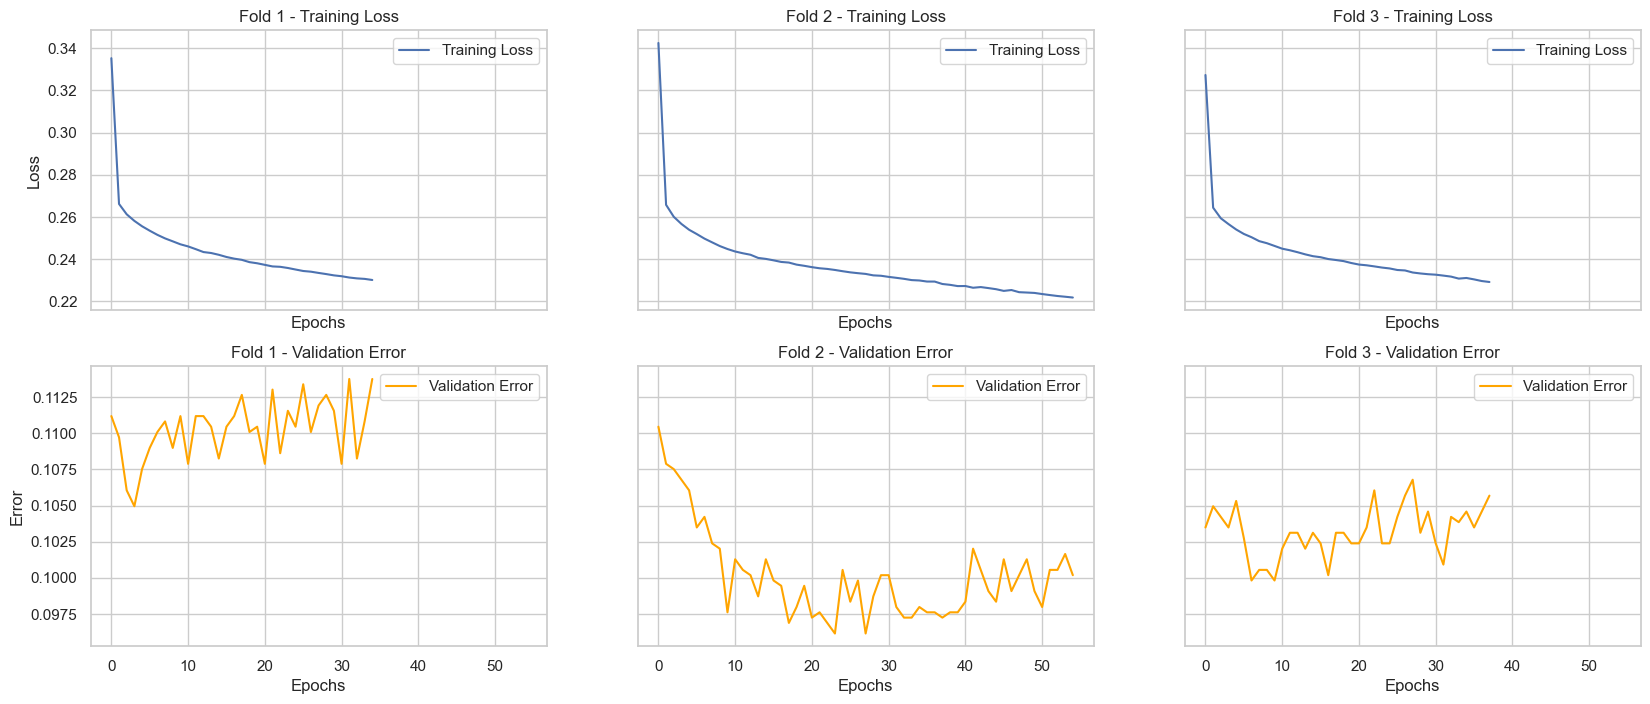

In [80]:
# plot training loss and validation loss for each fold

fig, axes = plt.subplots(2, 3, figsize=(20, 8), sharex=True)

min_loss = None
max_loss = None
min_err = None
max_err = None

for idx, res in enumerate(exp_1_res):
    ax_loss = axes[0, idx]
    ax_err = axes[1, idx]

    if idx == 0:
        ax_loss.set_ylabel('Loss')
        ax_err.set_ylabel('Error')
    else:
        ax_loss.set_yticklabels([])
        ax_err.set_yticklabels([])

    ax_loss.plot(res['train_loss'], label='Training Loss')
    ax_loss.set_title(f'Fold {res["fold"]} - Training Loss')
    ax_loss.set_xlabel('Epochs')
    ax_loss.legend()


    ax_err.plot([1 - score for score in res['validation_scores']], label='Validation Error', color='orange')
    ax_err.set_title(f'Fold {res["fold"]} - Validation Error')
    ax_err.set_xlabel('Epochs')
    ax_err.legend()


def get_limits(data):
    d_min, d_max = np.nanmin(data), np.nanmax(data)
    pad = (d_max - d_min) * 0.05
    return d_min - pad, d_max + pad

loss_lim = get_limits(np.concatenate([res['train_loss'] for res in exp_1_res]))
err_lim = get_limits(np.concatenate([[1 - score for score in res['validation_scores']] for res in exp_1_res]))

for i in range(3):
    axes[0, i].set_ylim(loss_lim)
    axes[1, i].set_ylim(err_lim)

plt.show()

## 4. Second experiment: awake / n-rem / rem 

Classify between the three states « awake », « n-rem » and « rem ».  

*Questions to ask yourselves:*

- What do you need to change compared to the previous experiment? 
- How many outputs neurons should we have? 
- How to encode the model's output when there's more than two classes? (take a look at one-hot encoding) 
- Is the target encoding different if you use « tanh » instead of  « sigmoid » for the outputs activation function? 
- How to decide which class is predicted? 
- If you have « tanh » or « sigmoid » as the output activation function and if you decide which class is predicted with a threshold (e.g. > 0 or > 0.5): 
    - Is it possible: 
        - That multiple class are predicted 
        - That no class is predicted 
    - What could we do instead of using a threshold? 

## 5. Competition: awake / n-rem / rem 

Same experiment as the second one but this time you're free to do any modifications you want 
as long as it's still an MLP. You can change how you validate the model if you want. Just make 
sure to give the important details in your report. 

Join your results on the test data (make sure to preprocess the test data the same way you 
preprocessed your training data before predicting on it). 

The first three groups will have a bonus. 

### What you need to do: 

- Implement at least one new idea. 
- You don't need to apply more than one idea if you don't want to. This competition is there to 
    motivate you, not to burden you with a lot of work. Only the top 3 winners will appear in the 
    ranking, but we will inform you of your score and rank privately. 
- It can be ideas from this list but can also be other ideas you find yourselves. 

### Ideas: 
- Change [optimizer](https://keras.io/api/optimizers/) (e.g. Adam instead of SGD) 
- Change last layer activation function by « softmax » (for each output of the model we will 
    predict a probability and the sum of the output values equal to 1). 
- Use [CategoricalCrossentropy](https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-class) (which is a loss meant for classification, ) instead of « MSE » 
- Use an [ensemble  of models]((https://machinelearningmastery.com/model-averaging-ensemble-for-deep-learning-neural-networks/)) (train multiple models, average their predictions) 

## 6. Submission 

Provide your report, your notebook(s) and your prediction on the competition test set. 
Report must be a PDF. Don't forget to include all your group members names in the report! 

**Competition's predictions:**

Save your results in a file named « test_pred.npy » and add it to your submission. Make sure the 
order of your predictions is correct (don't shuffle test set…). 

test_predictions must be a numpy array with the name of the sleep stages you predicted. 
We cannot know what sleep stage you refer to if you have them as integer! 

Example: `array(['n', 'w', 'r', …])`

```py
with open('test_pred.npy', 'wb') as f: 
    np.save(f, test_predictions)
```